#### Telco Customer Churn - Full EDA


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
FIG_DIR = "figures/eda"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", None)

def save(fig_name):
    plt.savefig(f"{FIG_DIR}/{fig_name}.png", bbox_inches="tight", dpi=120)


## A. Load Data

In [2]:
df = pd.read_csv("/home/saad-s-linux/Documents/Telco Customer Churn Prediction/data/Raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## B. Structure

In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## C. Fix TotalCharges (loads as object due to blank strings)

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges NaNs after conversion:", df["TotalCharges"].isnull().sum())

TotalCharges NaNs after conversion: 11


## D. Missing Values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

TotalCharges    11
dtype: int64

## E. Duplicates

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customerIDs: 0


## F. Numeric Summary

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## G. Categorical Value Counts

In [8]:
cat_cols = df.select_dtypes(include="object").columns.drop("customerID")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport:
TechSupport
No   

## H. Target Distribution (class imbalance check)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


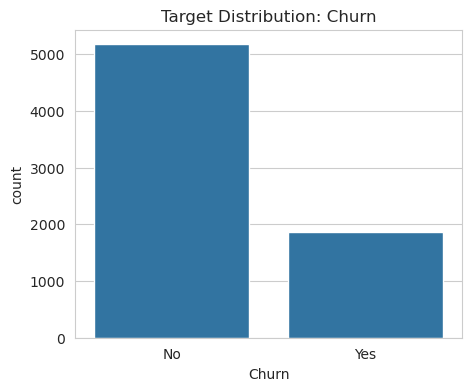

In [9]:
print(df["Churn"].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Target Distribution: Churn")
save("h_target_distribution")
plt.show()

## I. Univariate - Numeric Distributions

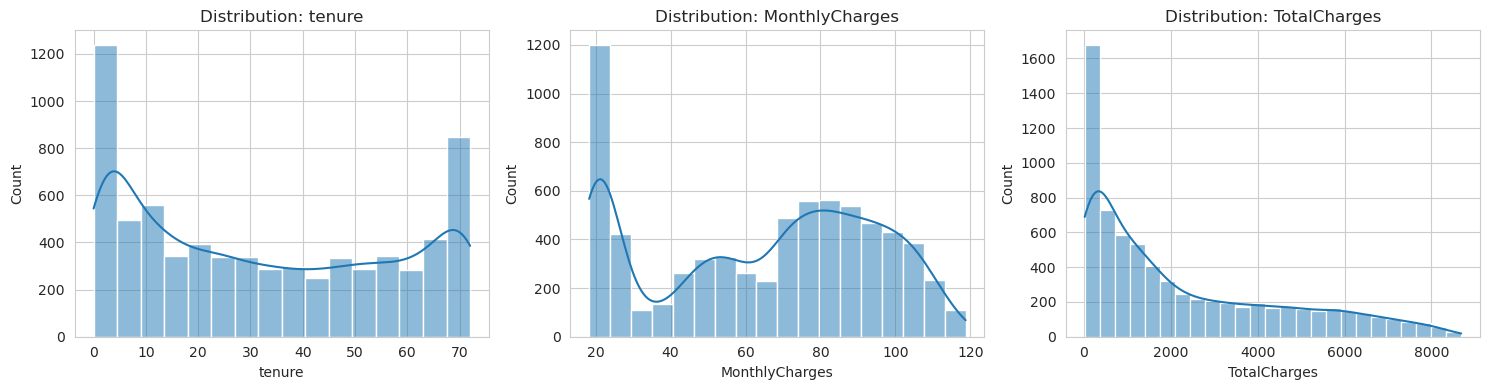

In [10]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
save("i_numeric_distributions")
plt.show()

## J. Outlier Check (boxplots)

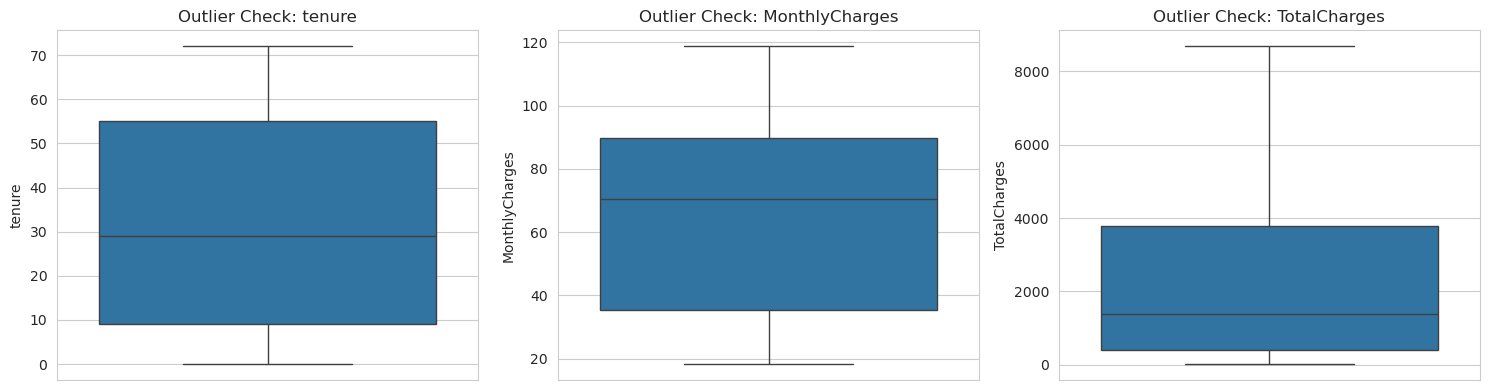

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Outlier Check: {col}")
plt.tight_layout()
save("j_outlier_check")
plt.show()

## K. Categorical Counts (key features)

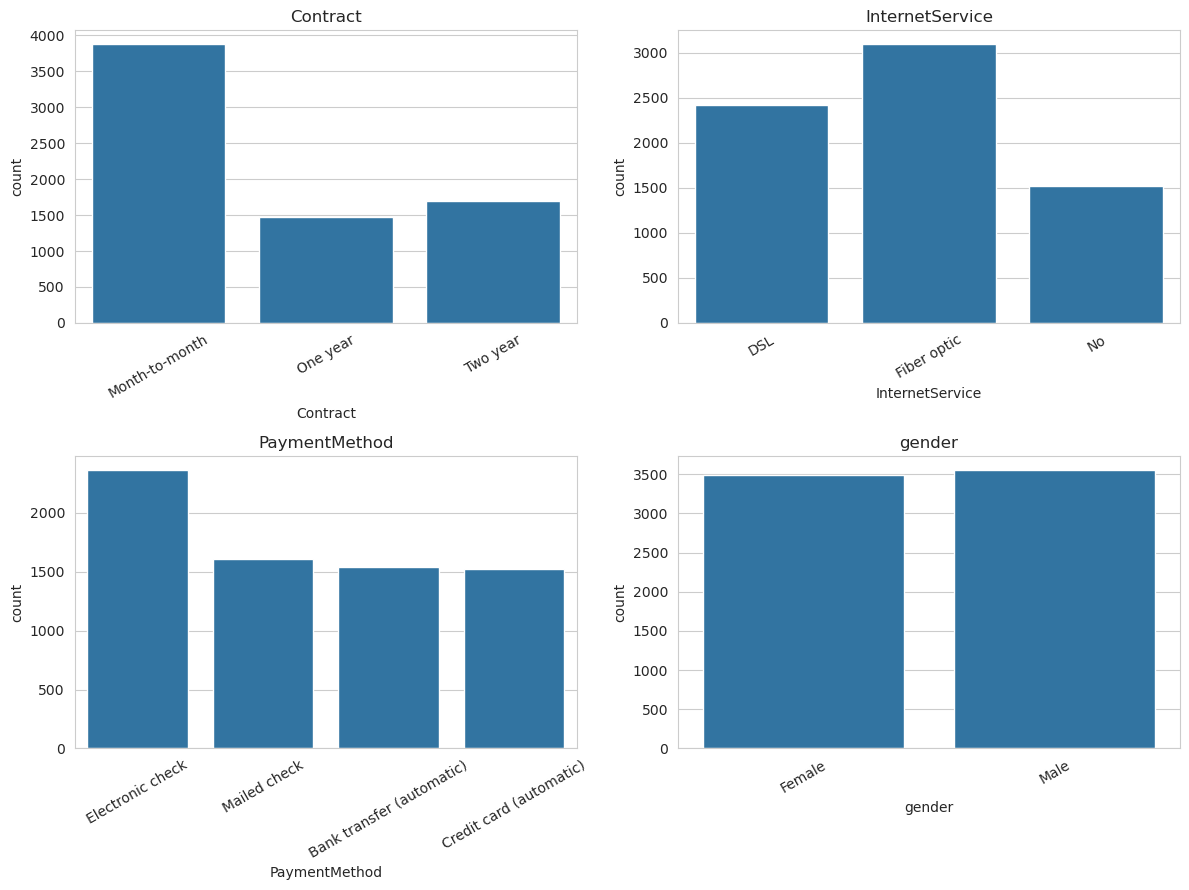

In [12]:
key_cats = ["Contract", "InternetService", "PaymentMethod", "gender"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flatten(), key_cats):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save("k_categorical_counts")
plt.show()

## L. Numeric Features vs Churn

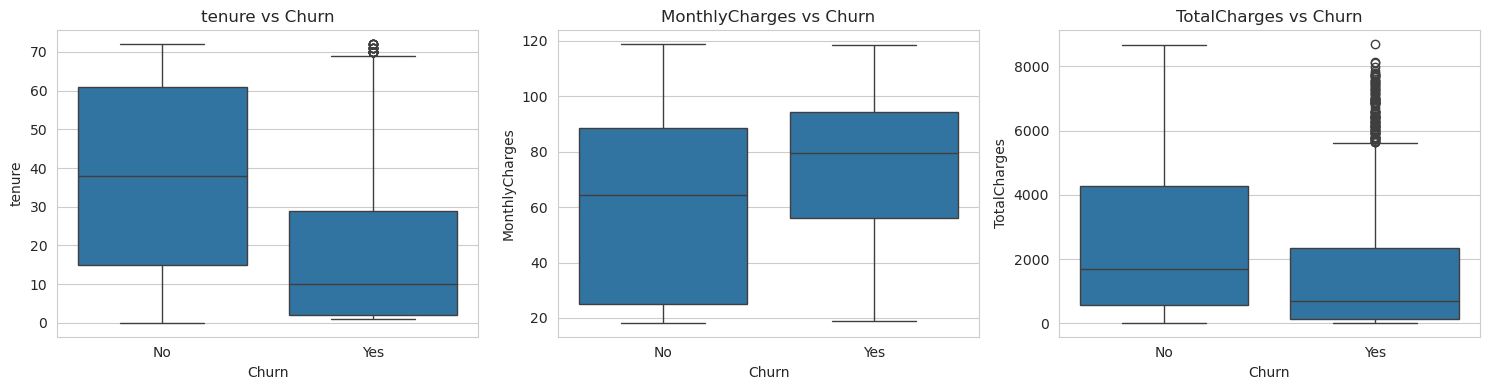

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
save("l_numeric_vs_churn")
plt.show()

## M. Categorical Features vs Churn (churn rate per category)

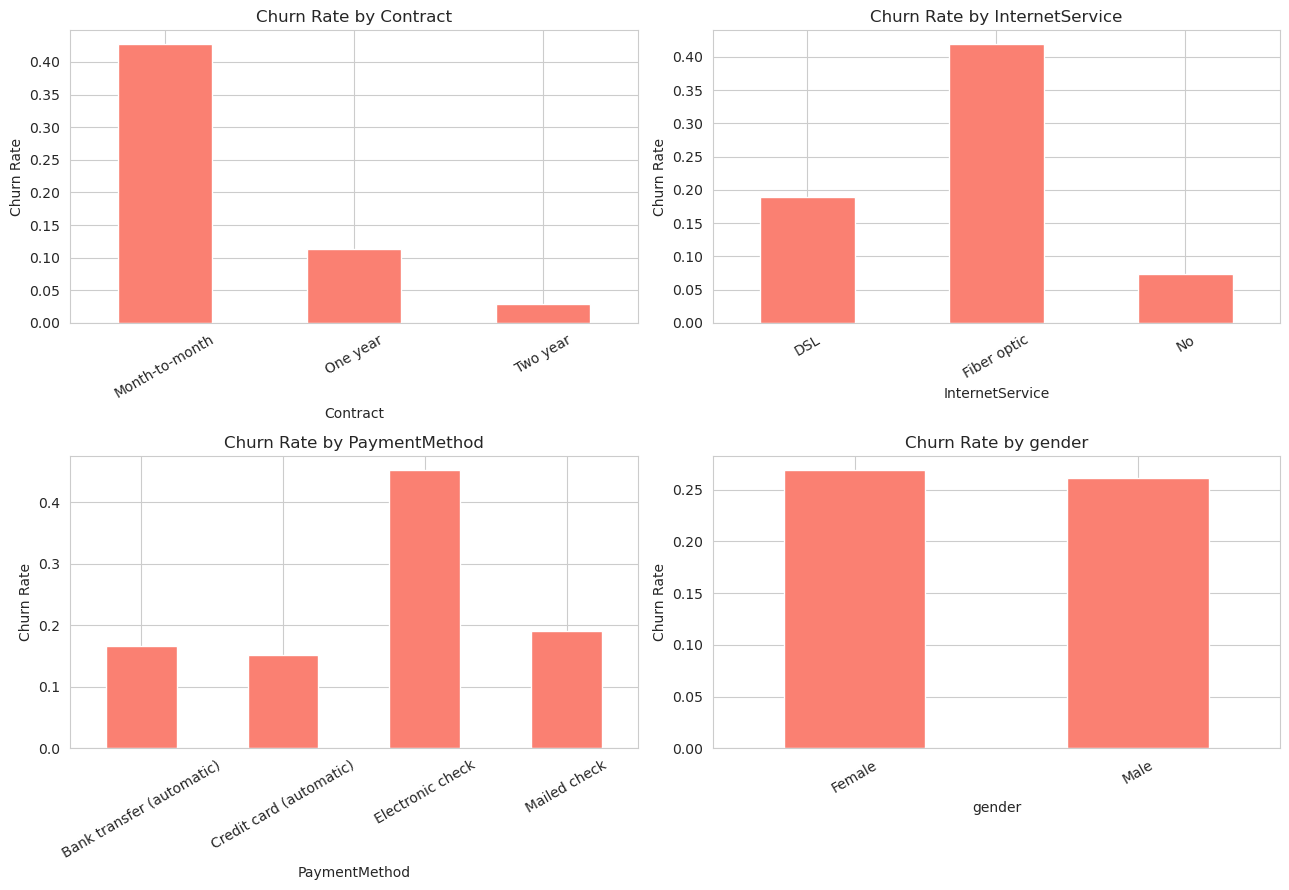

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), key_cats):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=ax, color="salmon")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
save("m_churn_rate_by_category")
plt.show()

## N. Add-on Services vs Churn

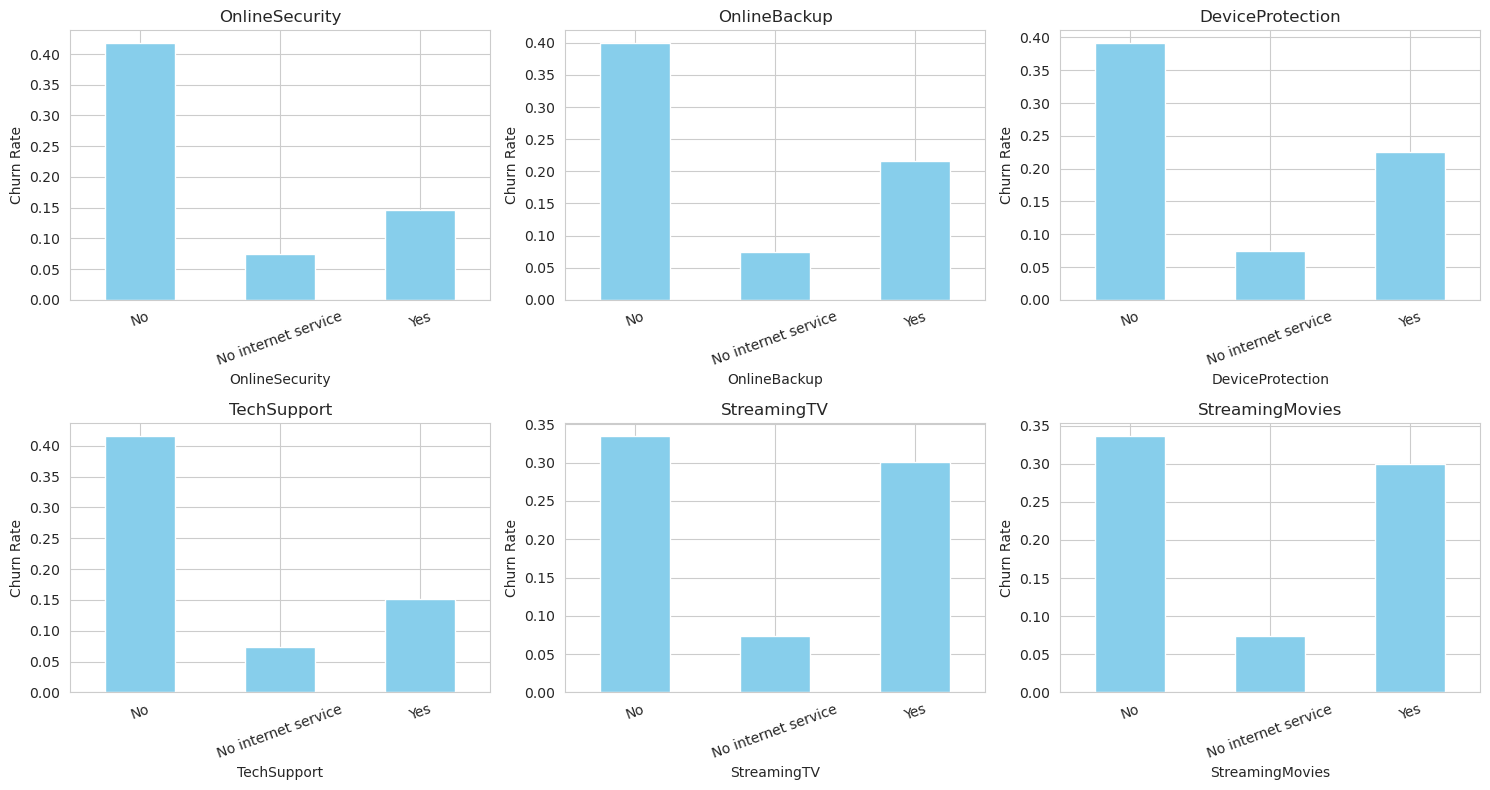

In [15]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), service_cols):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=ax, color="skyblue")
    ax.set_title(col)
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
save("n_services_vs_churn")
plt.show()

## O. Demographics vs Churn

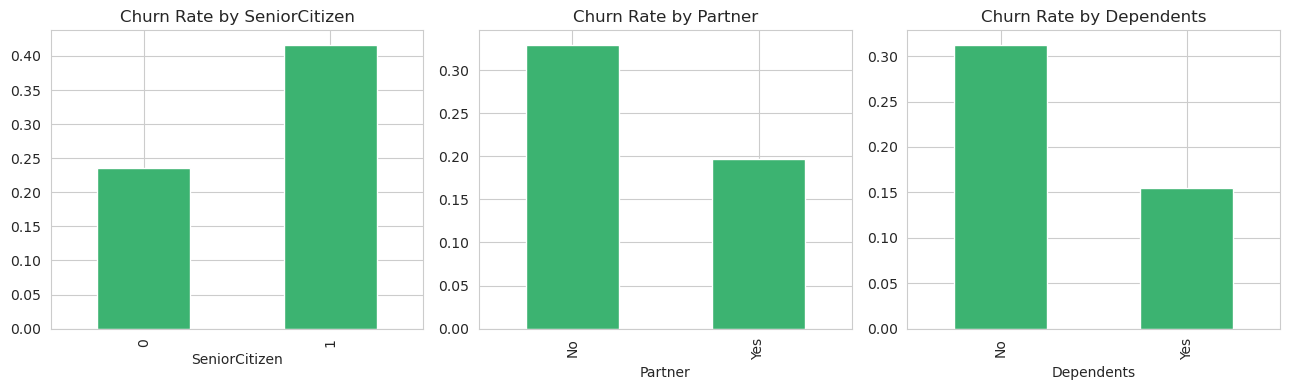

In [16]:
demo_cols = ["SeniorCitizen", "Partner", "Dependents"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, demo_cols):
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=ax, color="mediumseagreen")
    ax.set_title(f"Churn Rate by {col}")
plt.tight_layout()
save("o_demographics_vs_churn")
plt.show()

## P. Correlation Heatmap

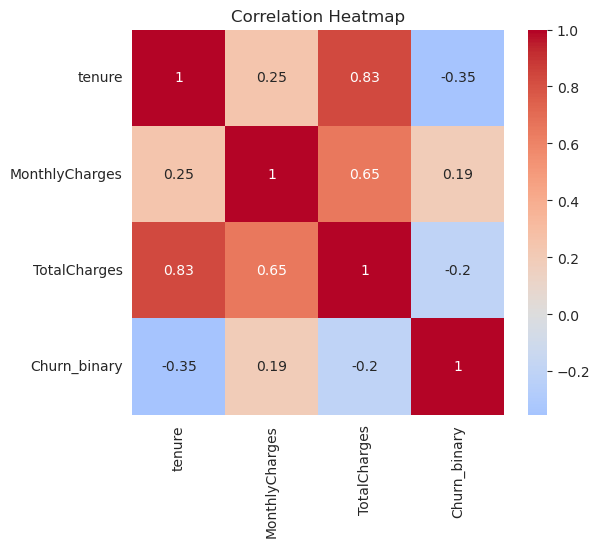

In [17]:
corr_df = df[numeric_cols].copy()
corr_df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
save("p_correlation_heatmap")
plt.show()

## Q. Tenure Buckets vs Churn

/tmp/ipykernel_41725/2208726796.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby("tenure_group")["Churn"].apply(lambda x: (x == "Yes").mean())


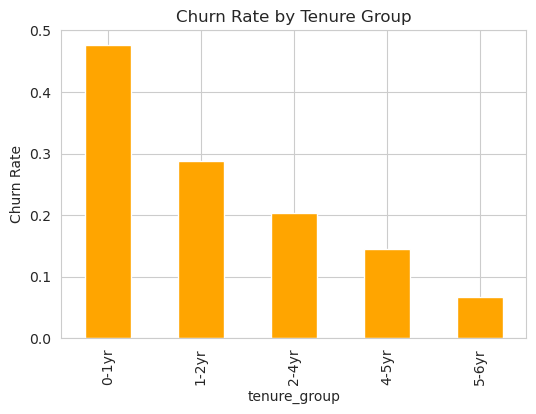

In [18]:
df["tenure_group"] = pd.cut(
    df["tenure"], bins=[0, 12, 24, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5-6yr"]
)
plt.figure(figsize=(6, 4))
churn_rate = df.groupby("tenure_group")["Churn"].apply(lambda x: (x == "Yes").mean())
churn_rate.plot(kind="bar", color="orange")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
save("q_tenure_group_vs_churn")
plt.show()

## R. Monthly Charges by Internet Service Type

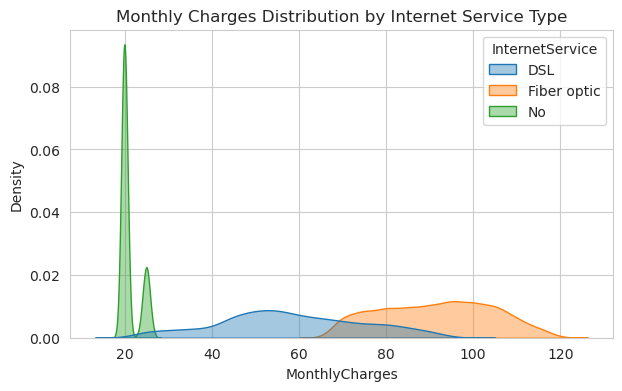

In [19]:
plt.figure(figsize=(7, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="InternetService", fill=True, alpha=0.4)
plt.title("Monthly Charges Distribution by Internet Service Type")
save("r_charges_by_internet_service")
plt.show()

## S. Payment Method vs Churn

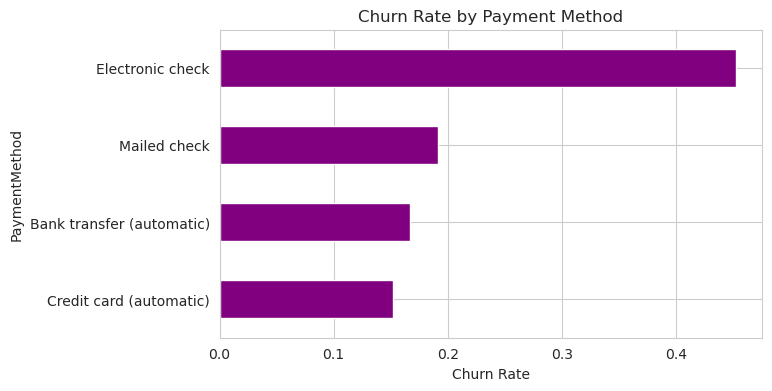

In [20]:
plt.figure(figsize=(7, 4))
churn_rate = df.groupby("PaymentMethod")["Churn"].apply(lambda x: (x == "Yes").mean())
churn_rate.sort_values().plot(kind="barh", color="purple")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate")
save("s_payment_method_vs_churn")
plt.show()

## T. Pairplot (numeric features colored by churn)

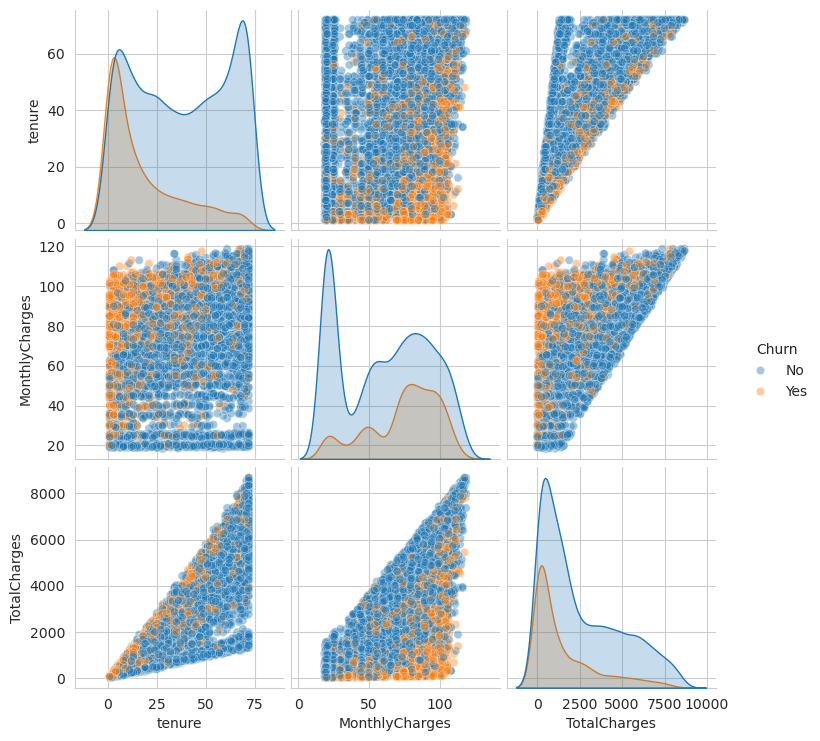

In [21]:
sample_df = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].dropna()
g = sns.pairplot(sample_df, hue="Churn", diag_kind="kde", plot_kws={"alpha": 0.4})
g.savefig(f"{FIG_DIR}/t_pairplot.png", bbox_inches="tight", dpi=120)
plt.show()

## U. Skewness / Kurtosis

In [24]:
print("Skewness:")
print(df[numeric_cols].skew())
print("\nKurtosis:")
print(df[numeric_cols].kurtosis())

Skewness:
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64

Kurtosis:
tenure           -1.387372
MonthlyCharges   -1.257260
TotalCharges     -0.231799
dtype: float64


## V. Sanity Checks

In [25]:
print("Min tenure:", df["tenure"].min(), "| Max tenure:", df["tenure"].max())
print("Min MonthlyCharges:", df["MonthlyCharges"].min(), "| Max:", df["MonthlyCharges"].max())
print("Negative values anywhere?", (df[numeric_cols] < 0).any().any())

Min tenure: 0 | Max tenure: 72
Min MonthlyCharges: 18.25 | Max: 118.75
Negative values anywhere? False


## W. High-Risk Segment (business insight)

In [26]:
risky_segment = df[
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["InternetService"] == "Fiber optic")
]
print(f"High-risk segment size: {len(risky_segment)} customers")
print("Churn rate in this segment:", (risky_segment["Churn"] == "Yes").mean())
print("Overall churn rate for comparison:", (df["Churn"] == "Yes").mean())

High-risk segment size: 916 customers
Churn rate in this segment: 0.7019650655021834
Overall churn rate for comparison: 0.2653698707936959


## X. Feature Summary Table

In [27]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isnull().sum(),
    "n_unique": df.nunique(),
})
summary.to_csv(f"{FIG_DIR}/feature_summary.csv")
summary

,dtype,n_missing,n_unique
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


## Y. Key Takeaways

- Target is imbalanced: ~73% stayed, ~27% churned -> use ROC-AUC/F1, not accuracy
- Month-to-month contracts + short tenure + fiber optic internet = highest churn risk
- Electronic check payment method correlates with higher churn
- Customers with more add-on services (security, backup, tech support) churn less
- TotalCharges has ~11 missing values, all customers with 0 tenure -> logical, not random